In [1]:
%load_ext autoreload
# %reload_ext autoreload
%autoreload 1

%aimport b6_epilepsies 
import b6_epilepsies as b6 #.py file in the same dir as this .ipynb
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# sns.set_theme(style="whitegrid", context="notebook", palette="muted")

# Define the custom color palette and genotype order
# new_colors_order = sns.color_palette(palette='Set2', n_colors=3)
# new_colors_order[0], new_colors_order[1], new_colors_order[2] = new_colors_order[1], new_colors_order[0], new_colors_order[2]
# color_map = dict(zip(['wt', 'het', 'hom'], new_colors_order))

# Define input variables
date   = "250214"
box1   = "14"
box2   = "15"
exp    = "ALDH7A1_20LYS_7dpf"
export = False

omit = {box1:['H7','D8','D9','D12']}
    
ald_lys_obj_raw = b6.RawData(date, box1, box2, exp, export) #.prepped_data attribute to access df

# ald_lys_obj_mid  = b6.MiddurData(date, box1, box2, exp, export, omit=omit) #.prepped_data attribute to access df
df_raw = ald_lys_obj_raw.df
all_seizure_df = ald_lys_obj_raw.generate_all_seizure_df()

Initialising RawData...
Start of experiment: 2025-02-14 10:07:08
Instantiated using 250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_processed.csv, no need to prepare raw data.
Done.
Generating all_seizure_df...
Done


In [ ]:
df_raw.head()

/var/folders/99/9p1rqw911_b36bj9w7ly35q80000gn/T/ipykernel_7235/4237994958.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_smoothed = df.groupby(["box", "well"], group_keys=False).apply(smooth_group, sigma=sigma_value)


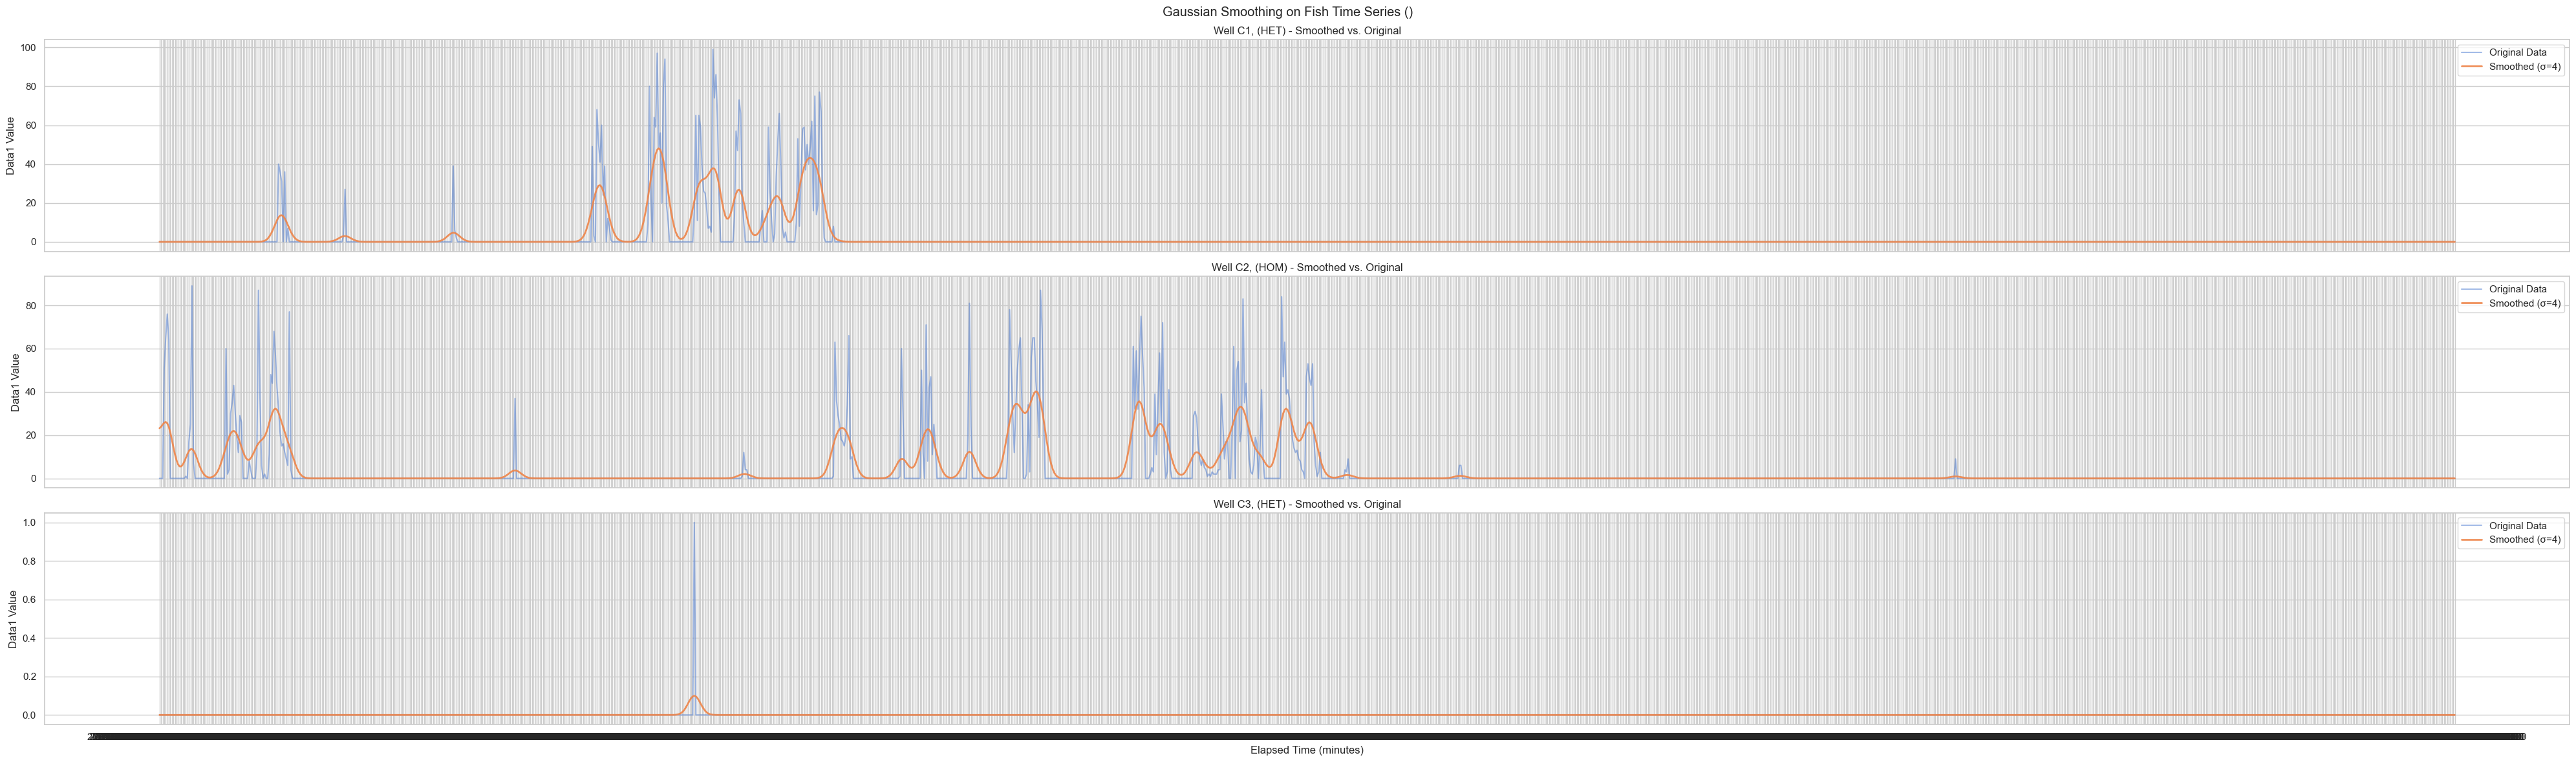

In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
sns.set_theme(style=None, context="notebook", palette="muted")


df = df_raw

# Convert elapsed_time to numeric (if needed)
df["elapsed_time"] = pd.to_numeric(df["elapsed_time"], errors="coerce")

# Function to apply Gaussian smoothing per fish (grouped by box and well)
def smooth_group(group, sigma=5):
    group = group.sort_values(by="elapsed_time")  # Ensure chronological order
    group["smoothed_data1"] = gaussian_filter1d(group["data1"], sigma=sigma)  # Apply smoothing
    return group

# Apply smoothing to each fish individually
sigma_value = 4  # Adjust smoothing level
df_smoothed = df.groupby(["box", "well"], group_keys=False).apply(smooth_group, sigma=sigma_value)

# **Filter by time elapsed in minutes**
df_smoothed_10min = df_smoothed[df_smoothed["elapsed_time"] <= 1]  # Now correctly using minutes

# **Select a few example wells to plot separately**
example_wells = df_smoothed_10min["well"].unique()[24:27]  # Pick first 3 wells
# example_wells = df_smoothed_10min["well"].unique()[24:28]  # Pick first 3 wells
num_wells = len(example_wells)

# Set up separate subplots for each well
fig, axes = plt.subplots(num_wells, 1, figsize=(40, 4 * num_wells), sharex=True)

if num_wells == 1:  # Ensure `axes` is iterable even if there's only one plot
    axes = [axes]

for ax, well in zip(axes, example_wells):
    well_data = df_smoothed_10min[df_smoothed_10min["well"] == well]
    genotype  = well_data['genotype'].unique()[0]
    ax.plot(well_data["fullts"], well_data["data1"], alpha=0.5, linestyle="solid", label="Original Data")
    ax.plot(well_data["fullts"], well_data["smoothed_data1"], label=f"Smoothed (σ={sigma_value})", linewidth=2, alpha=0.9)
    ax.set_title(f"Well {well}, ({genotype}) - Smoothed vs. Original")
    ax.set_ylabel("Data1 Value")
    ax.legend()

# Set common x-label
plt.xlabel("Elapsed Time (minutes)")
plt.suptitle("Gaussian Smoothing on Fish Time Series ()")
plt.tight_layout()
plt.show()

In [21]:
df_smoothed[df_smoothed['well']=='A2']

,fullts,elapsed_time,box,well,genotype,data1,smoothed_data1
1,2025-02-14 10:07:08.027045000,0.000000,14,A2,HOM,0.0,25.870186
64,2025-02-14 10:07:08.059016000,0.000533,14,A2,HOM,0.0,26.380693
127,2025-02-14 10:07:08.097652000,0.001177,14,A2,HOM,38.0,27.336302
190,2025-02-14 10:07:08.180832000,0.002563,14,A2,HOM,30.0,28.613499
253,2025-02-14 10:07:08.217890000,0.003181,14,A2,HOM,54.0,30.045716
...,...,...,...,...,...,...,...
18415657,2025-02-14 13:22:32.250190000,195.403719,14,A2,HOM,0.0,0.000000
18415720,2025-02-14 13:22:32.297120000,195.404501,14,A2,HOM,0.0,0.000000
18415783,2025-02-14 13:22:32.340895000,195.405231,14,A2,HOM,0.0,0.000000
18415846,2025-02-14 13:22:32.377325000,195.405838,14,A2,HOM,0.0,0.000000


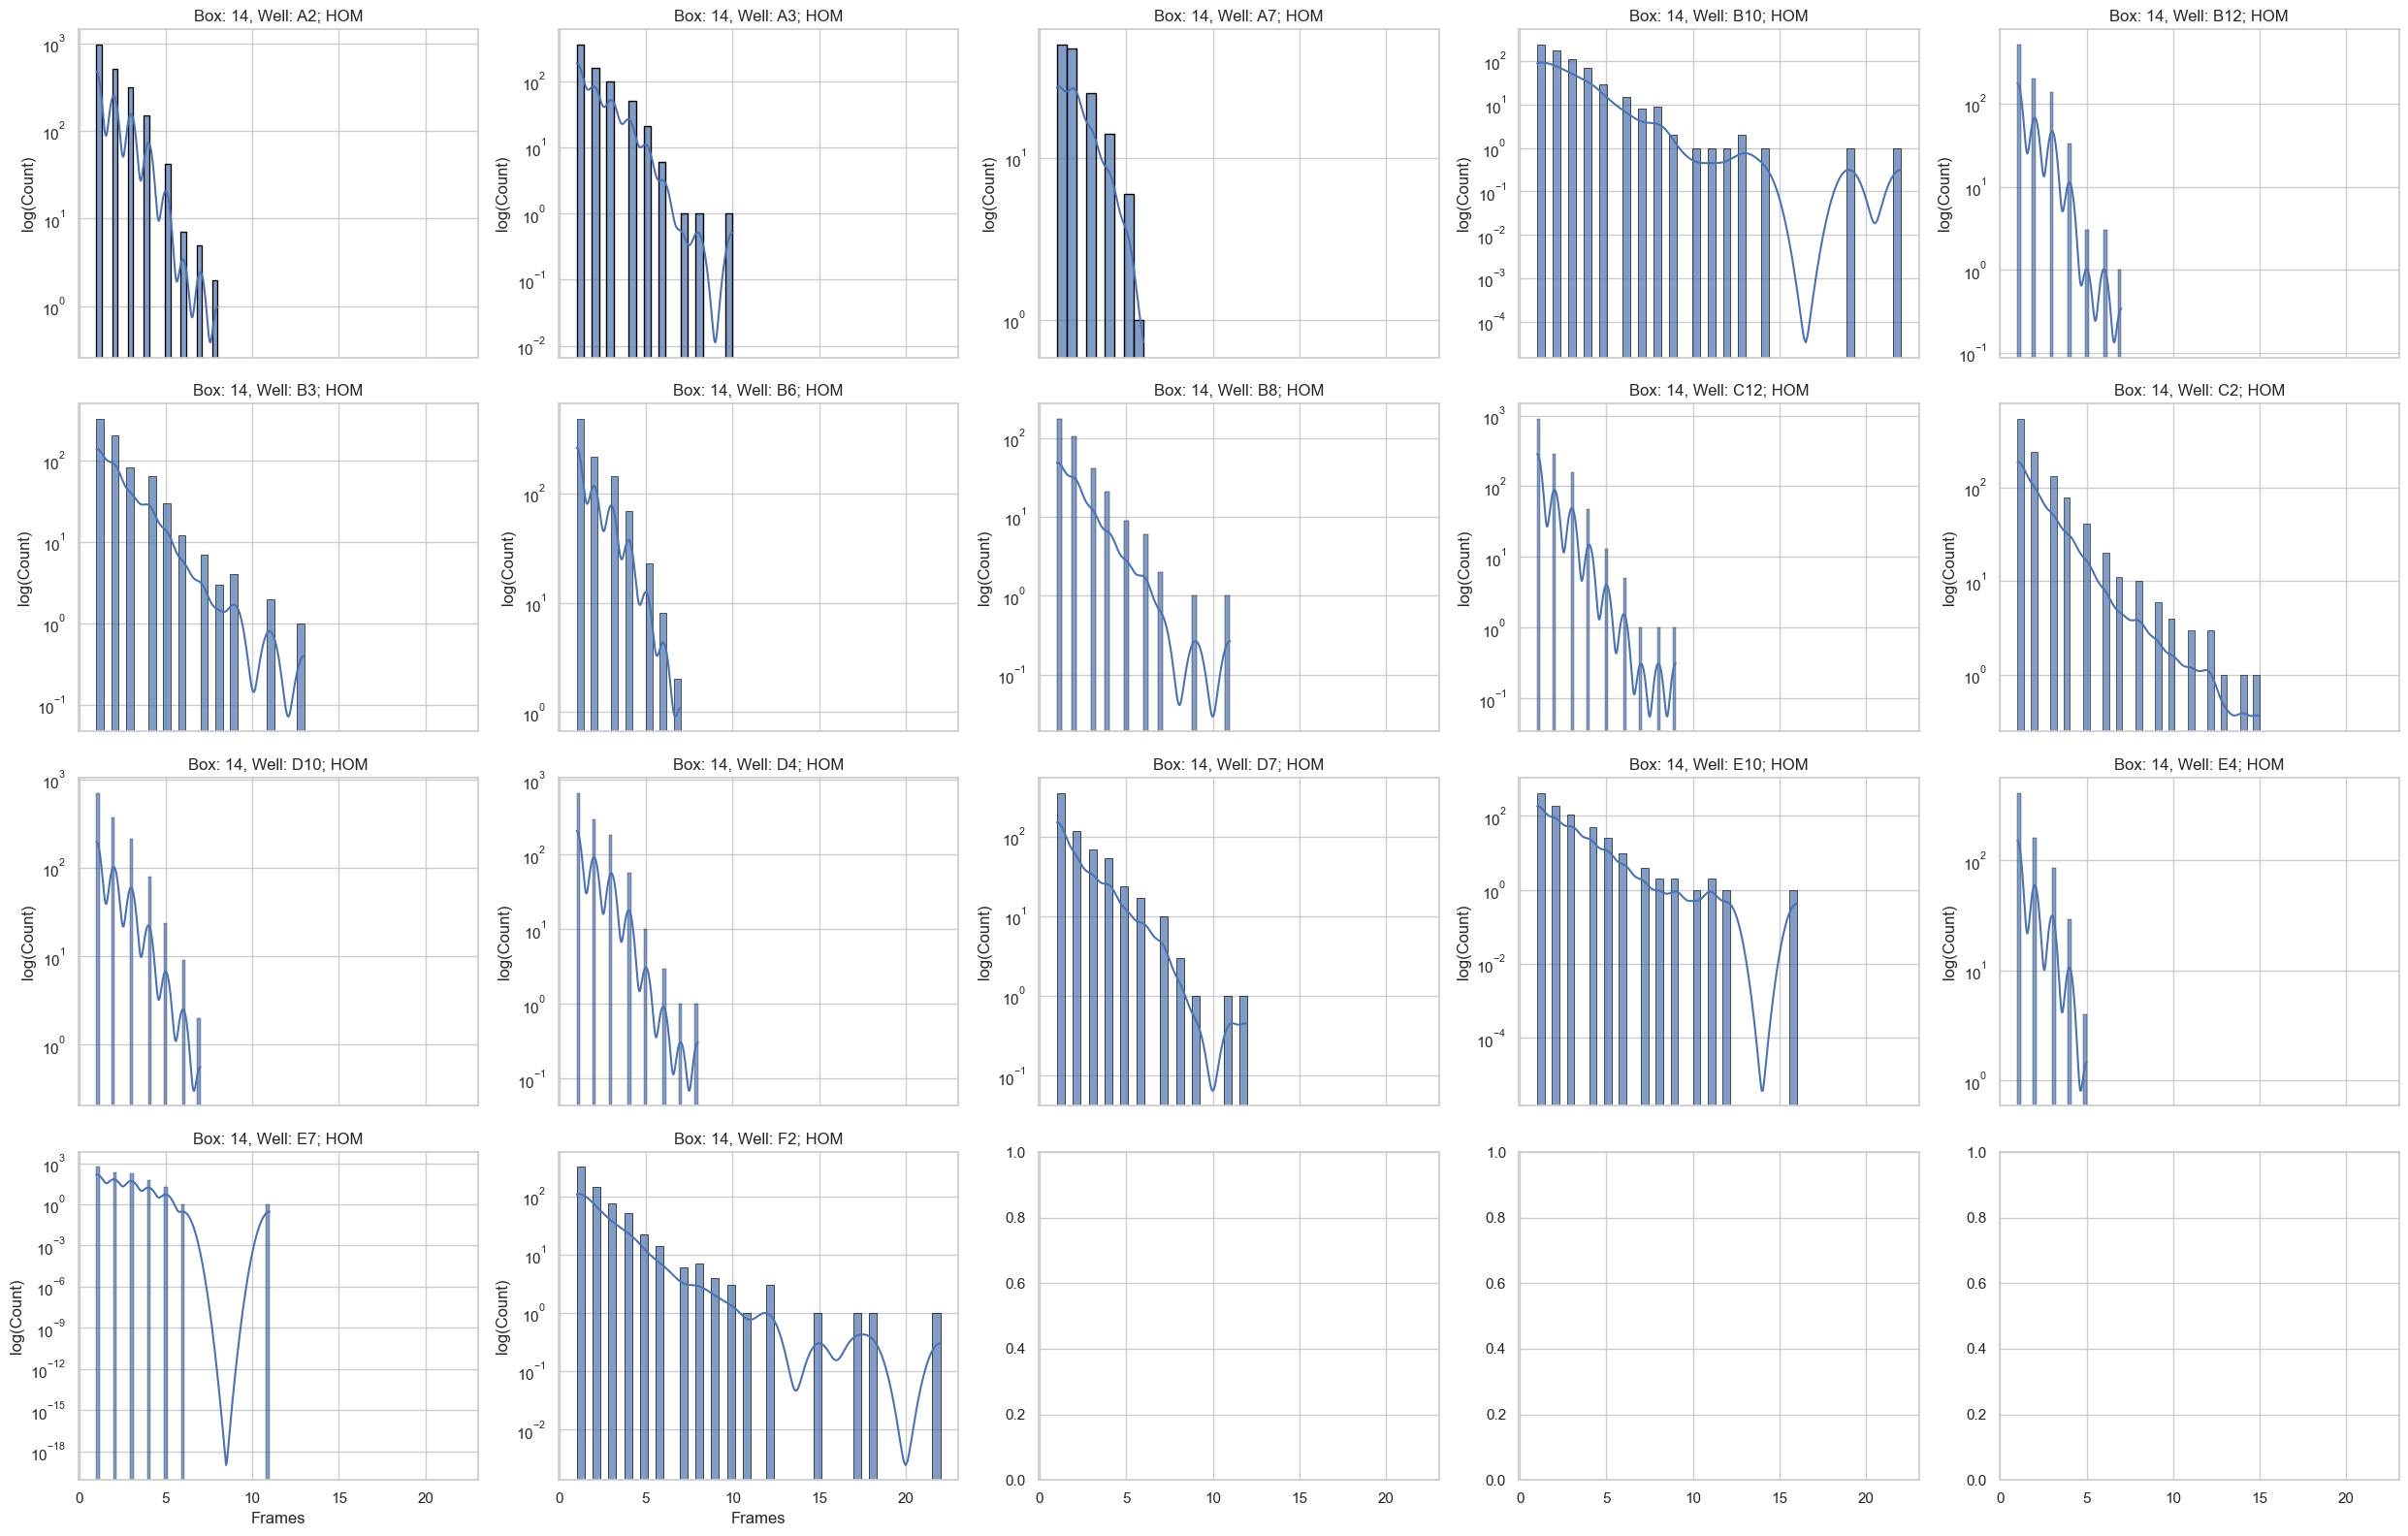

In [36]:
all_homs = df_raw[df_raw["genotype"] == "HOM"]
all_homs_grouped = list(all_homs.groupby(["box", "well"]))

# Extract (box, well) tuples
fish_list = [key for key, _ in all_homs_grouped]

# Pass all fish at once
ald_lys_obj_raw.plot_fish_count_hist(box_well_list=fish_list)

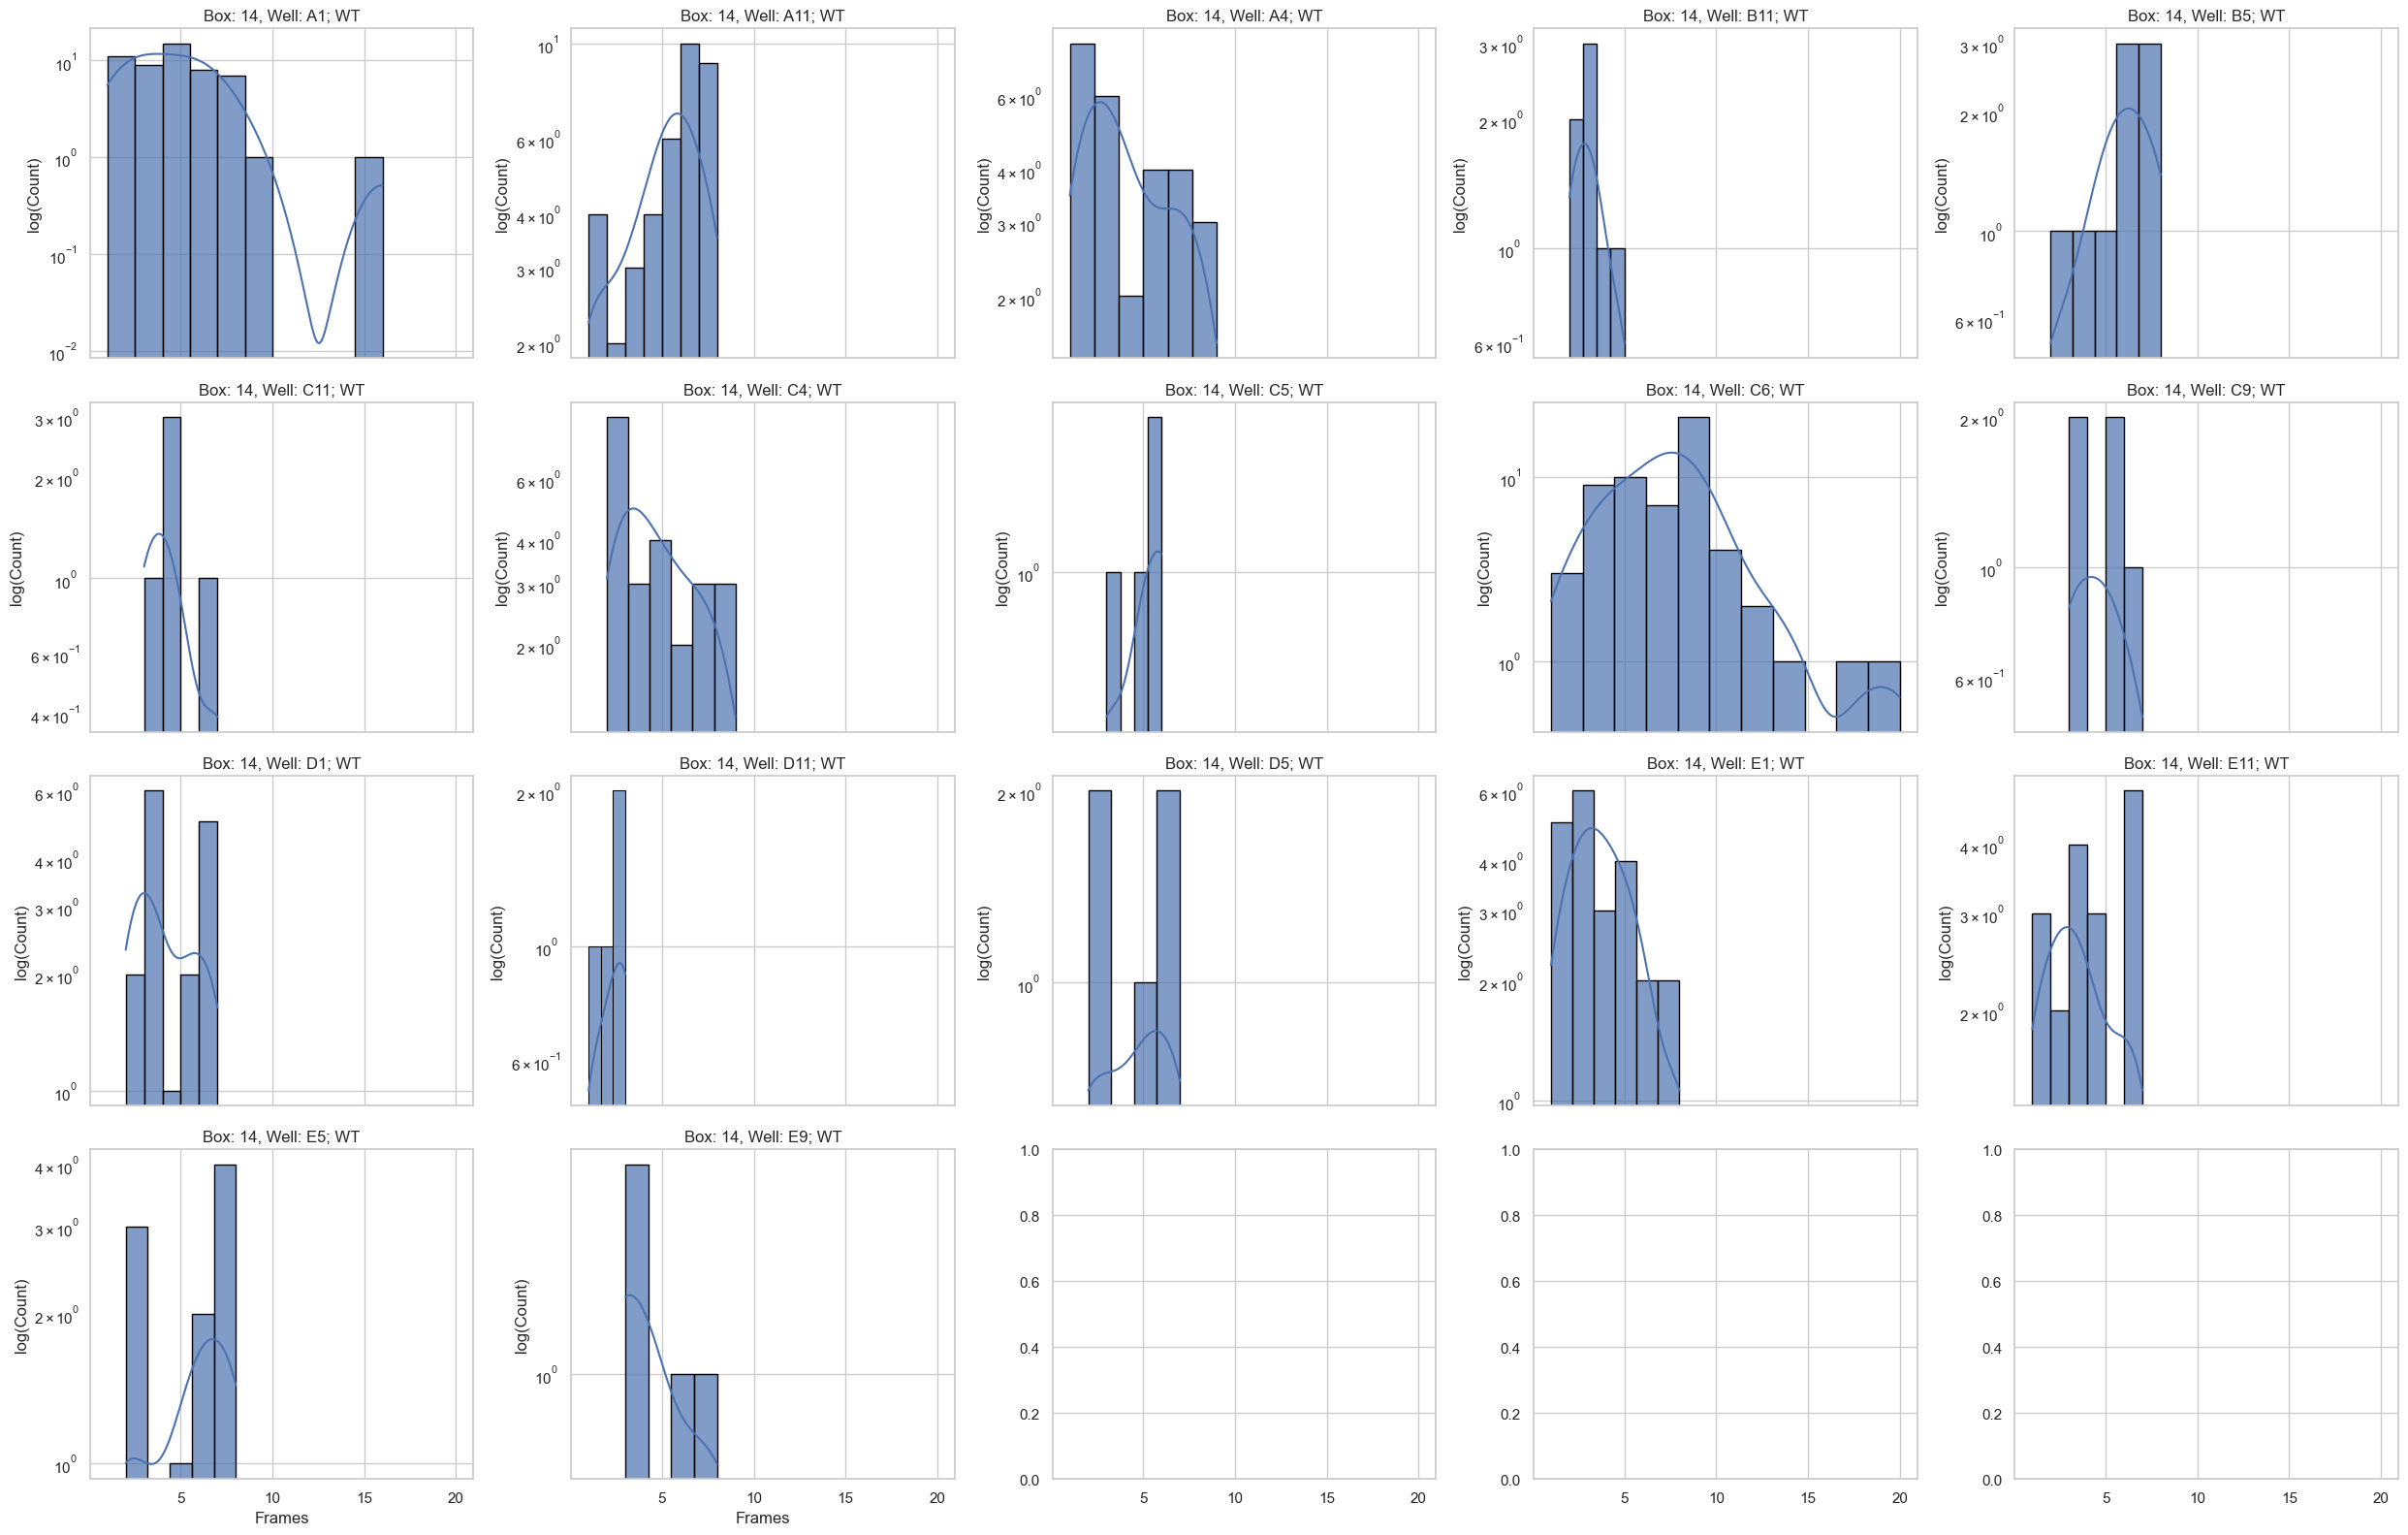

In [40]:
all_wts = df_raw[df_raw["genotype"] == "WT"]
all_wts_grouped = list(all_wts.groupby(["box", "well"]))

# Extract (box, well) tuples
fish_list = [key for key, _ in all_wts_grouped]

# Pass all fish at once
ald_lys_obj_raw.plot_fish_count_hist(box_well_list=fish_list, full_df=df_smoothed, col='smoothed_data1')


In [ ]:



fishC2        = df_raw[df_raw['well'] == 'C2'] #HOM

# Define threshold
threshold = 40

# Ensure data is sorted by time
df = fishC2.sort_values(by="fullts")

# Create a boolean column indicating if data1 is above the threshold
df["above_threshold"] = df["data1"] >= threshold

# Initialize variables
frame_count = 0
count_durations = []  # List to store number of frames in each threshold exceedance
above_threshold = False  # Track whether we're in a threshold-exceeding period

# Iterate through dataframe using .itertuples() (more efficient)
for row in df.itertuples(index=False):
    if row.above_threshold:
        if not above_threshold:  # First frame crossing threshold
            frame_count = 1  # Start counting
            above_threshold = True
        else:
            frame_count += 1  # Keep counting frames
    else:
        if above_threshold:  # Just dropped below threshold
            count_durations.append(frame_count)  # Store frame count
            above_threshold = False
            frame_count = 0  # Reset counter

# If the last value was still above the threshold, store the final count
if above_threshold:
    count_durations.append(frame_count)

# Output the frame count durations
print(f"Frame counts where data1 exceeded the threshold ({start}, {end}):", count_durations)
# fishA1_count_durations = count_durations
# ax = sns.histplot(fishA1_count_durations, kde=True, edgecolor="black", alpha=0.7)
# ax.set_yscale("log")

In [ ]:
fishC5 = df_raw[df_raw['well'] == 'C5'].copy()  # WT
seizure_df_C5 = ald_lys_obj_raw.detect_seizures(fishC5,  plot=True)

In [ ]:
fishD6 = df_raw[df_raw['well'] == 'D6'].copy()  # HET
seizure_df_D6 = ald_lys_obj_raw.detect_seizures(fishD6, plot=True)

In [319]:
fishC3 = df_raw[df_raw['well'] == 'C3'].copy()  # HET
seizure_df_C3 = ald_lys_obj_raw.detect_seizures(fishC3, plot=True)

Number of Seizure Events detected: 0 (C3, HET)


In [ ]:
fishA1 = df_raw[df_raw['well'] == 'A1'].copy()  # HOM
seizure_df_A1 = ald_lys_obj_raw.detect_seizures(fishA1, plot=True)

In [ ]:
fishC2 = df_raw[df_raw['well'] == 'C2'].copy()  # HOM
seizure_df_C2 = ald_lys_obj_raw.detect_seizures(fishC2, plot=True)

<AxesSubplot:xlabel='duration', ylabel='Count'>

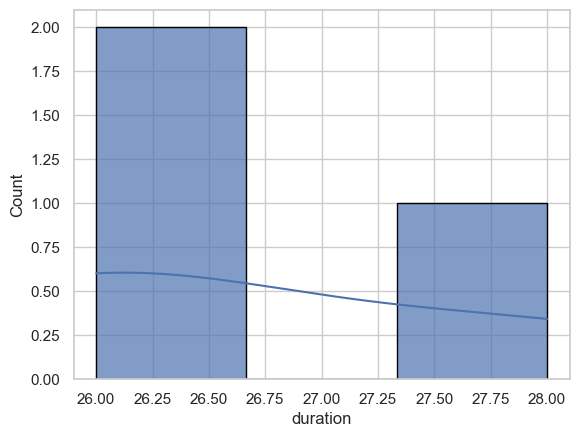

In [53]:
sns.histplot(seizure_df_A1['duration'], kde=True, edgecolor="black", alpha=0.7)

<AxesSubplot:xlabel='duration', ylabel='Count'>

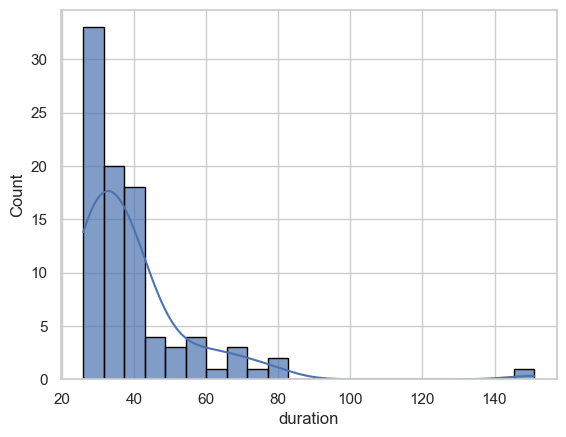

In [316]:
sns.histplot(seizure_df_C2['duration'], kde=True, edgecolor="black", alpha=0.7)

Seizure Duration Data Normal? False
Seizure Count Data Normal? False

Seizure Duration Test Used: Kruskal-Wallis | p = 0.0000
WT vs HET: p = 0.3981
WT vs HOM: p = 0.0011
HET vs HOM: p = 0.0000

Seizure Count Test Used: Kruskal-Wallis | p = 0.0098
WT vs HET: p = 0.4255
WT vs HOM: p = 0.0076
HET vs HOM: p = 0.0137
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT vs. HET: Custom statistical test, P_val:3.981e-01
HET vs. HOM: Custom statistical test, P_val:1.630e-05
WT vs. HOM: Custom statistical test, P_val:1.121e-03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT vs. HET: Custom statistical test, P_val:4.255e-01
HET vs. HOM: Custom statistical test, P_val:1.369e-02
WT vs. HOM: Custom statistical test

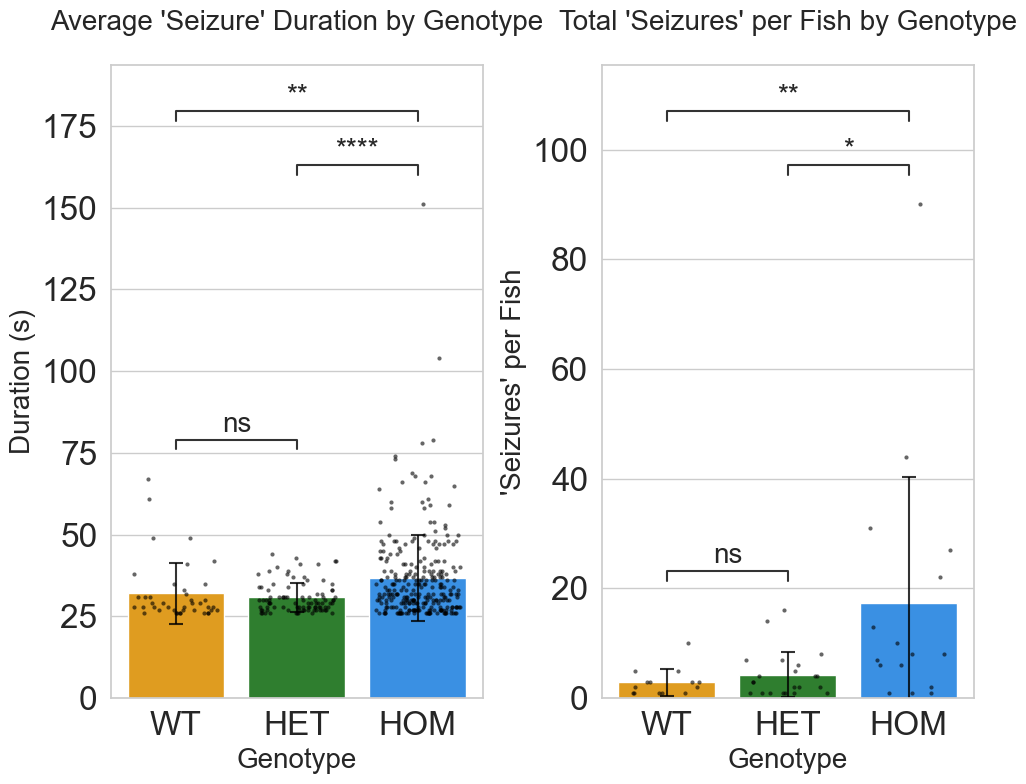

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, normaltest, kruskal, mannwhitneyu, f_oneway, ttest_ind
from statannotations.Annotator import Annotator

# Define genotype order and colors
genotype_order = ["WT", "HET", "HOM"]
genotype_colors = {"WT": "#FFA500", "HET": "#228B22", "HOM": "#1E90FF"}

# Ensure genotype is categorical
all_seizure_df['genotype'] = pd.Categorical(all_seizure_df['genotype'], categories=genotype_order, ordered=True)

# Step 1: Count seizures per fish (group by `box`, `well`)
seizure_counts_per_fish = all_seizure_df.groupby(["box", "well"]).size().reset_index(name="seizure_count")

# Step 2: Extract genotype for each fish (keep only first occurrence)
genotype_mapping = all_seizure_df.groupby(["box", "well"])["genotype"].first().reset_index()

# Step 3: Merge genotype back
seizure_counts_per_fish = seizure_counts_per_fish.merge(genotype_mapping, on=["box", "well"], how="left")

# Step 4: Compute summary statistics per genotype
genotype_stats = all_seizure_df.groupby(['genotype'], observed=False).agg(
    duration_mean=('duration', 'mean'),
    duration_std=('duration', 'std'),
    interbout_mean=('IBI', 'mean'),
    interbout_std=('IBI', 'std')
).reset_index()

# Fix: Group seizure_counts_per_fish by genotype, not well
genotype_stats_seizure_count = seizure_counts_per_fish.groupby(['genotype'], observed=False).agg(
    seizure_count_mean=('seizure_count', 'mean'),
    seizure_count_std=('seizure_count', 'std')
).reset_index()

# **Sort for proper ordering**
genotype_stats = genotype_stats.sort_values(by=['genotype'])
genotype_stats_seizure_count = genotype_stats_seizure_count.sort_values(by=['genotype'])


# **Step 5: Normality Tests**
normality_results = {}

for measure, data_source in [("duration", all_seizure_df), ("seizure_count", seizure_counts_per_fish)]:
    normality_results[measure] = {}
    
    for genotype in genotype_order:
        data = data_source.loc[data_source['genotype'] == genotype, measure]
        n = len(data)
        
        if n > 3:  # Ensure at least 3 values before running normality test
            shapiro_p = shapiro(data).pvalue
            dagostino_p = normaltest(data).pvalue if n >= 20 else None  # Skip `normaltest()` if n < 20
            
            normality_results[measure][genotype] = {
                "Shapiro-Wilk p": shapiro_p,
                "D’Agostino-Pearson p": dagostino_p
            }
        else:
            normality_results[measure][genotype] = {
                "Shapiro-Wilk p": None,
                "D’Agostino-Pearson p": None
            }


# Function to determine normality
def is_normal(p_values):
    return all(p >= 0.05 for p in p_values.values())

# Check normality
is_duration_normal = is_normal({g: normality_results["duration"][g]["Shapiro-Wilk p"] for g in genotype_order})
is_seizure_count_normal = is_normal({g: normality_results["seizure_count"][g]["Shapiro-Wilk p"] for g in genotype_order})

print(f"Seizure Duration Data Normal? {is_duration_normal}")
print(f"Seizure Count Data Normal? {is_seizure_count_normal}")

# **Step 6: Statistical Tests**
def run_statistical_tests(data, measure, is_normal):
    if is_normal:
        overall_p = f_oneway(*[data.loc[data['genotype'] == g, measure] for g in genotype_order]).pvalue
        test_name = "ANOVA"
        pairwise_tests = {pair: ttest_ind(
            data.loc[data['genotype'] == pair[0], measure],
            data.loc[data['genotype'] == pair[1], measure]
        ).pvalue for pair in pairwise_comparisons}
    else:
        overall_p = kruskal(*[data.loc[data['genotype'] == g, measure] for g in genotype_order]).pvalue
        test_name = "Kruskal-Wallis"
        pairwise_tests = {pair: mannwhitneyu(
            data.loc[data['genotype'] == pair[0], measure],
            data.loc[data['genotype'] == pair[1], measure]
        ).pvalue for pair in pairwise_comparisons}
    
    return test_name, overall_p, pairwise_tests


pairwise_comparisons = [("WT", "HET"), ("WT", "HOM"), ("HET", "HOM")]

# Run tests for both measures
duration_test_name, duration_p, duration_pairwise_tests = run_statistical_tests(all_seizure_df, "duration", is_duration_normal)
seizure_count_test_name, seizure_count_p, seizure_count_pairwise_tests = run_statistical_tests(seizure_counts_per_fish, "seizure_count", is_seizure_count_normal)

# Print results
print(f"\nSeizure Duration Test Used: {duration_test_name} | p = {duration_p:.4f}")
for pair, p_val in duration_pairwise_tests.items():
    print(f"{pair[0]} vs {pair[1]}: p = {p_val:.4f}")

print(f"\nSeizure Count Test Used: {seizure_count_test_name} | p = {seizure_count_p:.4f}")
for pair, p_val in seizure_count_pairwise_tests.items():
    print(f"{pair[0]} vs {pair[1]}: p = {p_val:.4f}")

# **Plotting**
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

def plot_with_points_and_error(ax, data, stats, y_col, y, std_col, y_label, title, p_values):
    sns.barplot(
        data=stats,
        x="genotype",
        y=y_col,
        errorbar=None,
        order=genotype_order, 
        ax=ax,
        hue="genotype",  # Explicitly set hue to match x-variable
        palette=genotype_colors,  
        legend=False  
    )
    sns.stripplot(
        data=data,
        x="genotype",
        y=y,
        dodge=False,
        jitter=0.35,
        order=genotype_order, ax=ax, color='black', alpha=0.6, size=3
    )
    ax.errorbar(
        stats["genotype"], stats[y_col], yerr=stats[std_col],
        fmt='none', ecolor='black', capsize=5, capthick=1.5, alpha=0.8
    )

    
    
    ax.set_title(title, fontsize=20, pad=25)
    ax.set_xlabel('Genotype', fontsize=20)
    ax.set_ylabel(y_label, fontsize=20)
    ax.set_ylim(0, data[y].max() * 1)  

    # plt.rcParams.update({
    #     'axes.titlesize': 24,     # subplot titles
    #     'axes.labelsize': 24,     # x/y axis labels
    #     'xtick.labelsize': 24,    # x-axis tick labels
    #     'ytick.labelsize': 24,    # y-axis tick labels
    #     'legend.fontsize': 28,    # legend text
    #     'figure.titlesize': 36    # overall figure title (if used)
    # })

    # **Statistical annotations**
    pairs = [("WT", "HET"), ("WT", "HOM"), ("HET", "HOM")]
    annotator = Annotator(ax, pairs, data=data, x="genotype", y=y, order=genotype_order)
    annotator.configure(test=None, text_format="star", loc="inside", fontsize=20)
    annotator.set_pvalues_and_annotate([p_values.get(pair, 1) for pair in pairs])

# **Plot 1: Seizure Duration**
plot_with_points_and_error(
    axes[0], all_seizure_df, genotype_stats, 
    "duration_mean", "duration", "duration_std", 
    "Duration (s)", "Average 'Seizure' Duration by Genotype", 
    duration_pairwise_tests
)

# **Plot 2: Seizure Count per Fish**
plot_with_points_and_error(
    axes[1], seizure_counts_per_fish, genotype_stats_seizure_count, 
    "seizure_count_mean", "seizure_count", "seizure_count_std", 
    "'Seizures' per Fish", "Total 'Seizures' per Fish by Genotype", 
    seizure_count_pairwise_tests
)



plt.tight_layout()
# Save figure with transparent background
# plt.savefig("250214_14_15_ALDH7A1_20LYS_7dpf.png", dpi=300, bbox_inches='tight', transparent=True)

save_path = f"250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_event_summary.svg"
# Save as SVG
plt.savefig(save_path, format='svg', bbox_inches='tight')
print(f"Plot saved to: {save_path}")
 
plt.show()

In [ ]:
# Define thresholds
# upper_threshold    = 35  # Activity level for potential seizure
# lower_threshold    = 2  # Defines "zero" or near-zero baseline
# min_frame_duration = 25  # Minimum frames required to qualify as a seizure event
# min_ibi            = 3  # Minimum interbout interval to confirm a separate event

# Ensure data is sorted by time (but maintain original index)
fish = fish.sort_values(by="fullts", ignore_index=True)

# Create a boolean column indicating if data1 is above the threshold
fish["above_threshold"] = fish["data1"] >= upper_threshold
fish["below_threshold"] = fish["data1"] <= lower_threshold

# Initialize variables
seizure_events = []  # Stores (start_index, end_index, duration, IBI)
temp_events    = []
in_seizure     = False  # Flag to track if we're currently in a seizure
start_index    = None  # To store the start of the bout
end_index      = None  # To store the end of the bout

next_start_index = None  # Tracks the next event's start

potential_event_end = None
frame_count = 0

# Convert DataFrame index to a list to ensure correct referencing
frame_indices = fish.index.tolist()

# Detect seizure events

for i, row in fish.iterrows():
    # print(i)
    if row["above_threshold"]:
        # print(f"^ this one is above threshold ({upper_threshold})")
        if not in_seizure:
            for j in range(i, -1, -1): # Look backward for bout start
                if fish.loc[j, 'below_threshold']:
                    start_index = j
                    # print("START: index=",start_index, "elapsed_time=",fishC2.loc[start_index, 'elapsed_time'])
                    break

            # Fix: If no below_threshold was found, default to i
            if start_index is None:
                start_index = i  # Assign i to prevent NoneType errors

            in_seizure  = True
            frame_count = 0

    else: # if row is not above upper threshold
        if in_seizure: # but still in seizure and data1 is below the lower threshold


            if row["below_threshold"]:
                # print(f"This is below the lower bound ({lower_threshold})")
                if potential_event_end == None:
                    potential_event_end = i
                else:
                    frame_count += 1
                # print(f"This is a potential end; {frame_count}")
            else:
                # print('Above lower threshold count:',frame_count)
                if frame_count <= min_ibi: # This means that the event is still ongoing
                    # duration  = potential_event_end - start_index
                    potential_event_end = frame_count
                    temp_event = (start_index, potential_event_end, frame_count, i)
                    temp_events.append(temp_event)
                    # print(f"temp_event: {temp_event}")
                    frame_count = 0

                elif len(temp_events)>0:
                    # print(f"temp_events: {temp_events}")
                    last_temp_event = temp_events.pop()

                    end_index = last_temp_event[3]+1
                    duration  = end_index - start_index
                    ibi       = (i-1) - end_index
                    # print(i)
                    event     = (start_index, end_index, duration, ibi)
                    if duration > min_frame_duration:
                        seizure_events.append(event)
                    temp_events     = []


                else:


                    end_index = potential_event_end
                    ibi       = frame_count
                    duration  = end_index - start_index
                    # print(temp_events)

                    if duration > min_frame_duration:
                        seizure_events.append((start_index, end_index, duration, ibi))
                        # print(f'START: {start_index}, END: {end_index}, ibi: {ibi}')
                        start_index = end_index + ibi

                    in_seizure = False
                    end_index = None
                    potential_event_end = None  # Reset temporary marker
                    frame_count = 0
                    # temp_events = []

#TODO
# if in_seizure:
#     duration = len(fishC2) - start_index
#     if duration > min_frame_duration:
#         ibi = start_index - last_end_index if last_end_index is not None else None
#         seizure_events.append((start_index, len(fishC2) - 1, duration, ibi))


    # if i == 300: break

# Convert seizure events to DataFrame
seizure_df = pd.DataFrame(seizure_events, columns=["start", "end", "duration", "IBI"])

# Convert 'duration' and 'IBI' to numeric immediately
seizure_df['duration'] = pd.to_numeric(seizure_df['duration'], errors='coerce')
seizure_df['IBI'] = pd.to_numeric(seizure_df['IBI'], errors='coerce')

b6.plot_events(fish, seizure_df, frame_indices, upper_threshold, lower_threshold)